In [242]:
import pandas as pd 

In [243]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score , f1_score

In [244]:
df = pd.read_csv(r"C:\Users\Simran Badwer\diabetes prediction.csv")

In [245]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,3,0,,0.0,0,0.0,1.406,22,1
1,5,?,0,0.0,0,NaN,0.727,68,0
2,3,?,64,0.0,0,32.4,missing,40,1
3,9,169,86,44.0,128,NaN,0.257,30,1
4,3,?,92,44.0,189,26.9,2.131,28,1


In [246]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [247]:
print(df.isnull().sum())

Pregnancies                  0
Glucose                     26
BloodPressure                0
SkinThickness               39
Insulin                      0
BMI                         32
DiabetesPedigreeFunction     0
Age                          0
Outcome                      0
dtype: int64


In [248]:
df.dropna()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,3,0,,0.0,0,0.0,1.406,22,1
2,3,?,64,0.0,0,32.4,missing,40,1
4,3,?,92,44.0,189,26.9,2.131,28,1
6,6,197,85,17.0,44,0.0,missing,51,1
11,7,165,58,50.0,202,0.0,1.343,60,1
13,4,170,77,0.0,?,0.0,1.762,24,1
14,2,191,0,15.0,0,38.5,1.489,37,1
17,12,106,69,50.0,0,0.0,0.479,65,1
22,4,143,0,0.0,0,26.2,1.686,68,1
23,12,?,90,10.0,?,23.7,missing,40,1


In [249]:
print(df.shape)

(100, 9)


In [250]:
X = df[['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age']]

Y = df['Outcome']


In [251]:
import numpy as np
X = X.replace(['?' , 'nan', 'missing',' ', ''], np.nan)
X = X.apply(pd.to_numeric, errors ='coerce')
X = X.fillna(X.mean())
print(X.isnull().sum())

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
dtype: int64


In [252]:
for col in X.columns:
  if X[col].dtype == 'object':
     print(col, X[col].unique())

In [253]:
print(X.dtypes)

Pregnancies                   int64
Glucose                     float64
BloodPressure               float64
SkinThickness               float64
Insulin                     float64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
dtype: object


In [254]:
print(X.shape)
print(Y.shape)

(100, 8)
(100,)


In [255]:
print(X_train.isnull().sum())

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
dtype: int64


In [256]:
X_train, X_test, Y_train , Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [257]:
model = LogisticRegression()

In [258]:
model.fit(X_train, Y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [261]:
model_prediction = model.predict(X_test)

In [262]:
print("accuracy_score: ", accuracy_score(Y_test, model_prediction))
print("precision_score: ", precision_score( Y_test, model_prediction))
print("recall_score: ", recall_score(Y_test,model_prediction) )
print("f1_score: ", f1_score(Y_test, model_prediction))

accuracy_score:  0.4
precision_score:  0.2857142857142857
recall_score:  0.6666666666666666
f1_score:  0.4


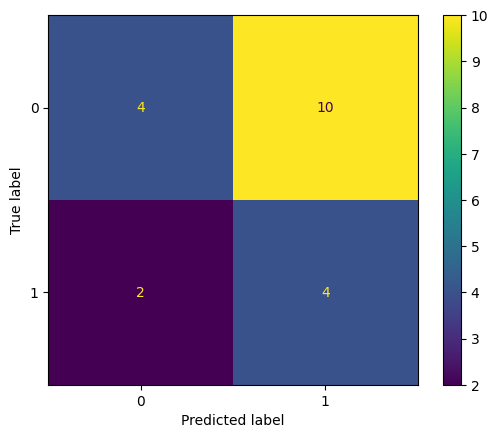

In [264]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(Y_test, model_prediction)